# 🏦 Loan Prediction Project

Predicting whether a bank loan application should be **Approved** or **Rejected** based on the applicant's personal and financial information, using **Logistic Regression** and **Random Forest** classifiers.

**Dataset:** Loan Prediction Problem Dataset (Kaggle)

**Workflow:**
1. Data Loading & Exploration
2. Data Cleaning (missing values, duplicates)
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Encoding & Scaling
6. Model Training (Logistic Regression & Random Forest)
7. Model Evaluation & Feature Importance
8. Predicting a New Applicant

## 1. Import Libraries
Loading all the libraries needed for data handling, visualization, preprocessing, and modeling.

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,classification_report, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/altruistdelhite04/loan-prediction-problem-dataset/test_Y3wMUE5_7gLdaTN.csv
/kaggle/input/datasets/altruistdelhite04/loan-prediction-problem-dataset/train_u6lujuX_CVtuZ9i.csv


## 2. Load the Dataset
Reading the training data into a DataFrame and previewing the last few rows.

In [2]:
df=pd.read_csv("/kaggle/input/datasets/altruistdelhite04/loan-prediction-problem-dataset/train_u6lujuX_CVtuZ9i.csv")
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


## 3. Initial Data Exploration
Checking column types, summary statistics, and the percentage of missing values in each column.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.0,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.00,81000.0
CoapplicantIncome,614.0,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,146.412162,85.587325,9.0,100.0,128.0,168.00,700.0
Loan_Amount_Term,600.0,342.000000,65.120410,12.0,360.0,360.0,360.00,480.0
Credit_History,564.0,0.842199,0.364878,0.0,1.0,1.0,1.00,1.0


In [5]:
df.isna().sum()/len(df)*100

Loan_ID              0.000000
Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       8.143322
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

## 4. Handle Missing Values
- Categorical columns (`Gender`, `Married`, `Dependents`, `Self_Employed`) are filled with the **mode** (most frequent value).
- Numerical columns (`Credit_History`, `LoanAmount`, `Loan_Amount_Term`) are filled with the **median**, which is more robust to outliers than the mean.

In [6]:
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

In [7]:
df['Credit_History']=df["Credit_History"].fillna(df['Credit_History'].median())
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].median())

In [8]:
df.isna().sum()/len(df)*100

Loan_ID              0.0
Gender               0.0
Married              0.0
Dependents           0.0
Education            0.0
Self_Employed        0.0
ApplicantIncome      0.0
CoapplicantIncome    0.0
LoanAmount           0.0
Loan_Amount_Term     0.0
Credit_History       0.0
Property_Area        0.0
Loan_Status          0.0
dtype: float64

## 5. Check for Duplicate Rows

In [9]:
df.duplicated().sum()

np.int64(0)

## 6. Clean Categorical Values & Encode the Target
Converting `Dependents` (`3+`) to a numeric value, and mapping `Loan_Status` to `1` (Approved) / `0` (Rejected) so it can be used as the model target.

In [10]:
df['Dependents'] = df['Dependents'].replace('3+', '3').astype(int)
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

## 7. Exploratory Data Analysis (EDA)
Visualizing the target distribution and how key features relate to loan approval.

### 7.1 Loan Status Distribution
How many applicants were approved vs. rejected.

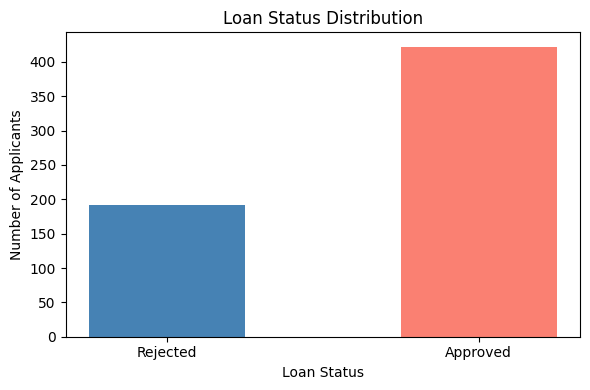

In [11]:
plt.figure(figsize=(6, 4))
colors = ["steelblue", "salmon"]
counts = df['Loan_Status'].value_counts().sort_index()
labels = ["Rejected", "Approved"]

plt.bar(labels, counts.values, color=colors, width=0.5)
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")
plt.tight_layout()
plt.show()

### 7.2 Loan Approval by Education

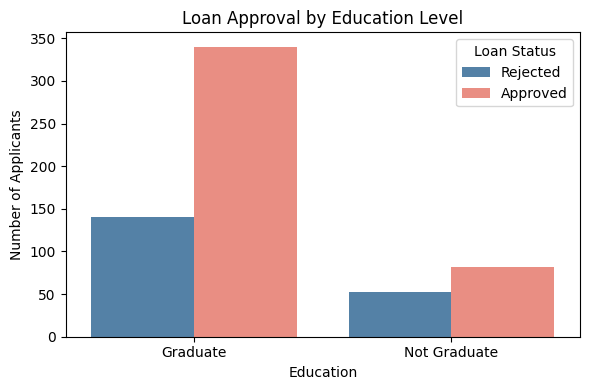

In [12]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x="Education", hue="Loan_Status", data=df, palette=["steelblue", "salmon"])
ax.set_xticklabels(["Graduate", "Not Graduate"])
plt.title("Loan Approval by Education Level")
plt.xlabel("Education")
plt.ylabel("Number of Applicants")
plt.legend(title="Loan Status", labels=["Rejected", "Approved"])
plt.tight_layout()
plt.show()

### 7.3 Loan Approval by Property Area

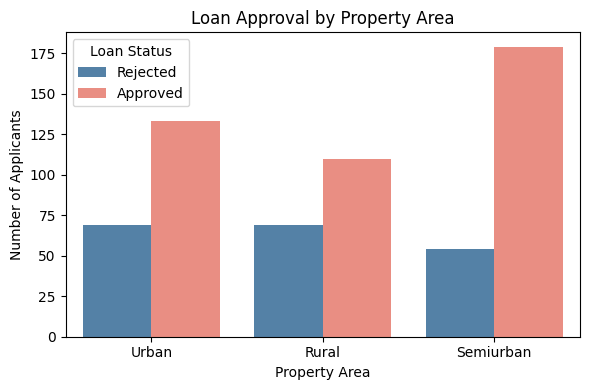

In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Property_Area", hue="Loan_Status", data=df, palette=["steelblue", "salmon"])
plt.title("Loan Approval by Property Area")
plt.xlabel("Property Area")
plt.ylabel("Number of Applicants")
plt.legend(title="Loan Status", labels=["Rejected", "Approved"])
plt.tight_layout()
plt.show()

### 7.4 Loan Approval by Gender

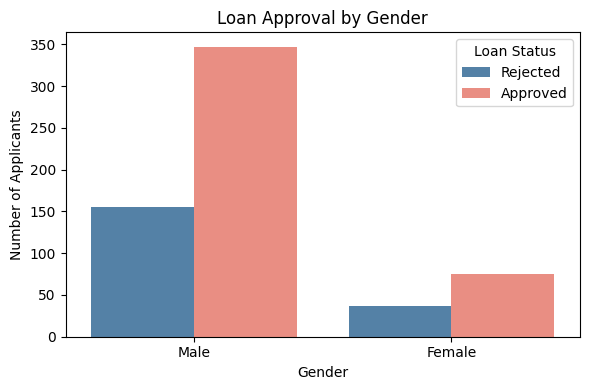

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Gender", hue="Loan_Status", data=df, palette=["steelblue", "salmon"])
plt.title("Loan Approval by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Applicants")
plt.legend(title="Loan Status", labels=["Rejected", "Approved"])
plt.tight_layout()
plt.show()

### 7.5 Correlation Heatmap
Looking at how the numerical features correlate with each other.

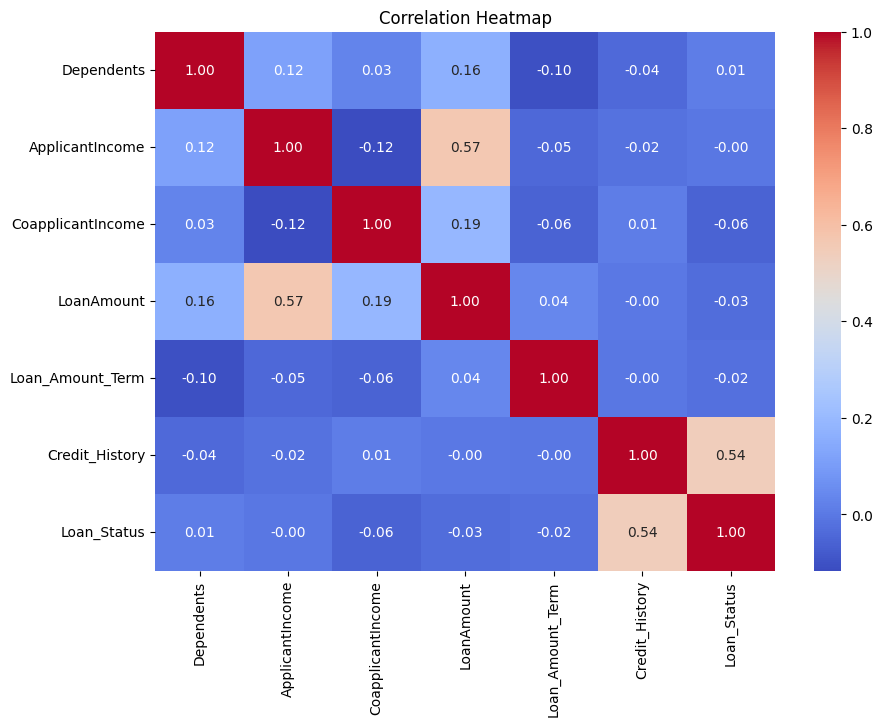

In [15]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Correlation Heatmap')
plt.show()

## 8. Feature Engineering
- Combining `ApplicantIncome` and `CoapplicantIncome` into a single `TotalIncome` feature.
- Applying a **log transform** to `LoanAmount` and `TotalIncome` to reduce right-skew and make the distributions more normal.
- Creating an `Income_Loan_Ratio` feature to capture how large the loan is relative to the applicant's income.

In [16]:
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

### 8.1 Total Income Distribution

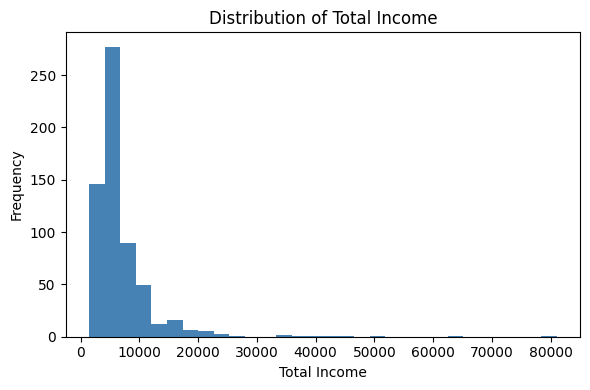

In [17]:
plt.figure(figsize=(6, 4))
plt.hist(df['TotalIncome'], bins=30, color="steelblue")
plt.title("Distribution of Total Income")
plt.xlabel("Total Income")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### 8.2 Loan Amount Distribution

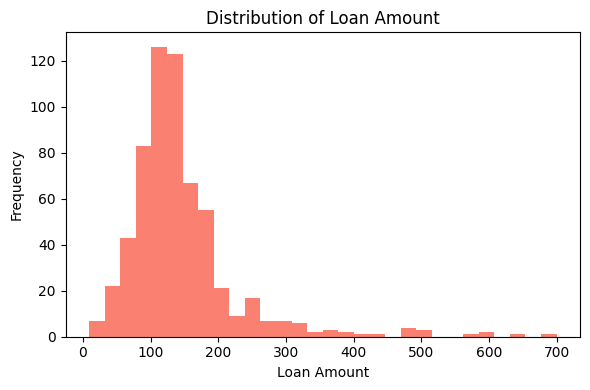

In [18]:
plt.figure(figsize=(6, 4))
plt.hist(df['LoanAmount'], bins=30, color="salmon")
plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [19]:
df['LoanAmount_log']   = np.log(df['LoanAmount'] + 1)
df['TotalIncome_log']  = np.log(df['TotalIncome'] + 1)

In [20]:
df["Income_Loan_Ratio"] = (
    df["TotalIncome"] /
    df["LoanAmount"]
)

## 9. Drop Redundant Columns
Removing the original income/loan-amount columns now that we have their engineered (log-transformed) versions.

In [21]:
df.drop(["ApplicantIncome", "CoapplicantIncome"], axis=1, inplace=True)
df.drop("TotalIncome", axis=1, inplace=True)
df.drop("LoanAmount", axis=1, inplace=True)

## 10. Encode Categorical Variables
Converting all remaining text columns into numeric codes using `LabelEncoder` so the models can process them.

In [22]:
encoder = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = encoder.fit_transform(df[col])

In [23]:
df.dtypes

Loan_ID                int64
Gender                 int64
Married                int64
Dependents             int64
Education              int64
Self_Employed          int64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
Loan_Status            int64
LoanAmount_log       float64
TotalIncome_log      float64
Income_Loan_Ratio    float64
dtype: object

In [24]:
df.drop('Loan_ID', axis=1, inplace=True)

In [25]:
df

,Gender,Married,Dependents,Education,Self_Employed,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,LoanAmount_log,TotalIncome_log,Income_Loan_Ratio
0,1,0,0,0,0,360.0,1.0,2,1,4.859812,8.674197,45.695312
1,1,1,1,0,0,360.0,1.0,0,0,4.859812,8.714732,47.585938
2,1,1,0,0,1,360.0,1.0,2,1,4.204693,8.006701,45.454545
3,1,1,0,1,0,360.0,1.0,2,1,4.795791,8.505525,41.175000
4,1,0,0,0,0,360.0,1.0,2,1,4.955827,8.699681,42.553191
...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,360.0,1.0,0,1,4.276666,7.972811,40.845070
610,1,1,3,0,0,180.0,1.0,0,1,3.713572,8.320448,102.650000
611,1,1,1,0,0,360.0,1.0,2,1,5.537334,9.025576,32.853755
612,1,1,2,0,0,360.0,1.0,2,1,5.236442,8.933796,40.550802


## 11. Define Features (X) and Target (y)

In [26]:
X = df.drop('Loan_Status', axis=1)  
y = df['Loan_Status']

## 12. Train-Test Split
Splitting the data into 80% training and 20% testing, stratified on the target so both sets keep the same approval/rejection ratio.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

## 13. Feature Scaling
Standardizing the features (mean = 0, std = 1) — required for Logistic Regression to converge properly and treat all features fairly.

In [28]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test) 

## 14. Model 1 — Logistic Regression
Training a baseline linear model on the scaled features.

In [29]:
lr = LogisticRegression(random_state=42)

lr.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [30]:
pred_lr = lr.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred_lr))

Accuracy: 0.8536585365853658


In [31]:
print("\n▸ Classification Report:")
print(classification_report(y_test, pred_lr))


▸ Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.55      0.70        38
           1       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



In [32]:
cm = confusion_matrix(y_test, pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Rejected', 'Approved'])

Visualizing the confusion matrix to see how many approvals/rejections were correctly and incorrectly predicted.

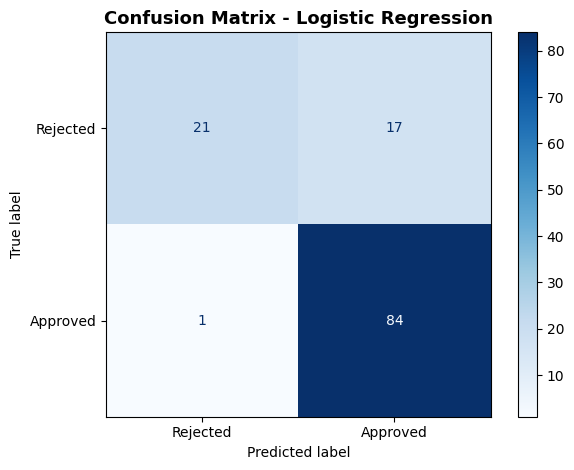

In [33]:
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression', fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix_lr.png", dpi=100)
plt.show()

## 15. Model 2 — Random Forest
Training a Random Forest classifier, which can capture non-linear relationships between features.

In [34]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=8, n_estimators=300, random_state=42)

In [35]:
pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_rf))

Accuracy: 0.8617886178861789


In [36]:
print("\n▸ Classification Report:")
print(classification_report(y_test, pred_rf))


▸ Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.66      0.75        38
           1       0.86      0.95      0.91        85

    accuracy                           0.86       123
   macro avg       0.86      0.81      0.83       123
weighted avg       0.86      0.86      0.86       123



In [37]:
cm = confusion_matrix(y_test, pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Rejected', 'Approved'])

Confusion matrix for the Random Forest model.

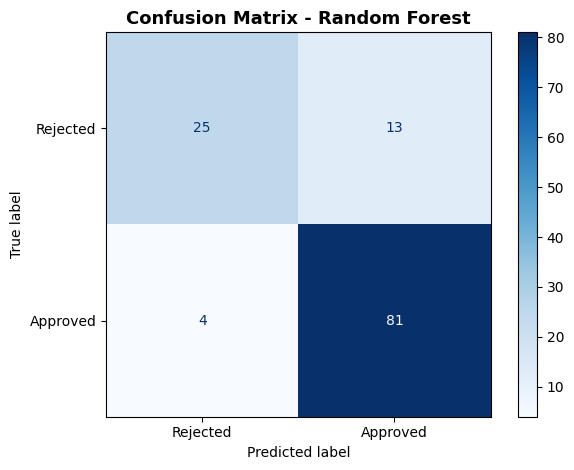

In [38]:
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Random Forest', fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix_rf.png", dpi=100)
plt.show()

## 16. Feature Importance (Random Forest)
Which features the Random Forest relied on most when making its predictions.

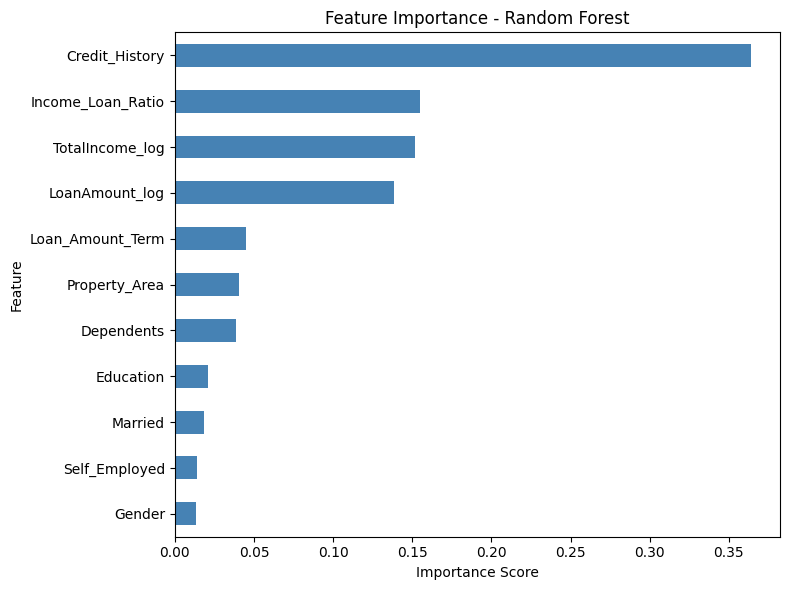

In [39]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values()

plt.figure(figsize=(8, 6))
importance.plot(kind="barh", color="steelblue")
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 17. Predict a New Applicant
Testing the trained Random Forest model on a single hypothetical applicant.


In [40]:
loan_amount = 180
total_income = 8500

new_applicant = {
    'Gender': 1,                 # Male
    'Married': 1,                # Yes
    'Dependents': 2,
    'Education': 0,              # Graduate
    'Self_Employed': 0,          # No
    'Loan_Amount_Term': 360,
    'Credit_History': 1,
    'Property_Area': 1,          # Semiurban
    'LoanAmount_log': np.log(loan_amount + 1),
    'TotalIncome_log': np.log(total_income + 1),
    'Income_Loan_Ratio': total_income / loan_amount
}

In [41]:
new_applicant = pd.DataFrame([new_applicant])
new_applicant = new_applicant[X.columns]

prediction = rf.predict(new_applicant)[0]
probability = rf.predict_proba(new_applicant)[0]


In [42]:
print("Prediction:", "Approved" if prediction == 1 else "Rejected")
print(f"Approval Probability: {probability[1]:.2%}")
print(f"Rejection Probability: {probability[0]:.2%}")

Prediction: Approved
Approval Probability: 80.53%
Rejection Probability: 19.47%


## 📌 Summary

**Goal:** predict whether a loan application will be approved or rejected using applicant demographic and financial data.

**Steps performed:**
- Cleaned missing values (mode for categorical columns, median for numerical columns) and checked for duplicates.
- Explored the data visually — approval rates by education, property area, and gender, plus a correlation heatmap.
- Engineered new features: `TotalIncome`, log-transformed `LoanAmount`/`TotalIncome` (to reduce skew), and an `Income_Loan_Ratio`.
- Encoded categorical variables and scaled the features for the linear model.
- Trained and compared two models:

| Model | Accuracy |
|---|---|
| Logistic Regression | ~85.4% |
| Random Forest | ~86.2% |

**Key findings:**
- `Credit_History` is the strongest predictor of loan approval, by a wide margin.
- The Random Forest slightly outperforms Logistic Regression overall, and is notably better at correctly identifying **rejected** applications (higher recall on class 0).
- Both models are much better at detecting approvals than rejections, which reflects the class imbalance in the dataset (more approved than rejected loans).